In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import scipy as sp
from matplotlib.lines import Line2D
import sys

sys.path.append("../../Modeling/fitting")
from optimization_utils import make_boundary

In [2]:
from matplotlib import font_manager

font_manager.fontManager.addfont("/home1/beigejin/Times.ttc")
plt.rc("font", family="serif", serif=["Times"])
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times"

# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
SAVEFIG = True
SAVERES = False

## Load Stimuli and Semantic Matrix

In [3]:
with open("simu2_data/simu2_design.pkl", "rb") as inp:
    df_study = pickle.load(inp)
    df_test = pickle.load(inp)
# df_study = df_study.query("session < 100")  # for testing
# df_test = df_test.query("session < 100")

In [4]:
df_study

,subject,list,itemno1,itemno2,study_pos,session
0,37,0,1154,-1,1,0
1,37,0,1121,-1,2,0
2,37,0,612,-1,3,0
3,37,0,907,-1,4,0
4,37,0,1358,-1,5,0
...,...,...,...,...,...,...
34939,172,5,1243,-1,60,90
34940,172,5,1077,-1,61,90
34941,172,5,1423,-1,62,90
34942,172,5,968,-1,63,90


In [5]:
df_test

,subject,list,recog_pos,itemno1,itemno2,old,old_lag,study_pos,study_lag,yes,session
0,37,0,1,195,-1,True,-999,9,56,1.0,0
1,37,0,2,493,-1,True,46,55,11,0.0,0
2,37,0,3,376,-1,True,-3,52,15,0.0,0
3,37,0,4,998,-1,True,-5,47,21,0.0,0
4,37,0,5,184,-1,False,-999,-99,-9999,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
69883,172,5,124,801,-1,False,-999,-99,-9999,0.0,90
69884,172,5,125,1335,-1,False,-999,-99,-9999,1.0,90
69885,172,5,126,1245,-1,True,-999,28,162,1.0,90
69886,172,5,127,747,-1,False,-999,-99,-9999,0.0,90


In [6]:
sem_mat = np.load("simu2_data/simu2_smat.npy")

## Run CMR-IA

In [7]:
# define parameters
params = cmr.make_default_params()
params.update(use_new_context=True, use_flexible_thresh=True, c_thresh_itm=1)

# load pso results
_, _, what_to_fit = make_boundary(sim_name="2")
optim_params = np.loadtxt("simu2_data/2_250531_200-200.txt")
for pname, pvalue in zip(what_to_fit, optim_params):
    params[pname] = pvalue
params

{'beta_enc': 0.258066,
 'beta_rec': 0.5,
 'beta_cue': 0.28766,
 'beta_rec_post': 0.029796,
 'beta_distract': 0.406914,
 'beta_enc_inpair': -1,
 'phi_s': 2,
 'phi_d': 0.5,
 's_fc': 0.758293,
 's_cf': 0,
 'kappa': 0.5,
 'eta': 0.5,
 'omega': 5,
 'alpha': 1,
 'lamb': 0.5,
 'c_thresh': 0.5,
 'c_thresh_itm': 1,
 'c_thresh_assoc': 0.5,
 'd_assoc': 0,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 50,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'use_new_context': True,
 'psi_s': 0,
 'psi_c': 1,
 'c_s': 0,
 'thresh_sigma': 0,
 'ban_recall': None,
 'use_var_enc': False,
 'var_enc_p': None,
 'bad_enc_ratio': None,
 'recog_slope': 1,
 'use_flexible_thresh': True,
 'thresh_rate': 5.171985,
 'thresh_kernel_len': 10,
 'gamma_fc': 0.07213,
 'gamma_cf': 0.5}

In [8]:
for key in what_to_fit:
    print(f"{key}: {params[key]:.3f}")

beta_enc: 0.258
beta_cue: 0.288
beta_distract: 0.407
beta_rec_post: 0.030
s_fc: 0.758
gamma_fc: 0.072
thresh_rate: 5.172


In [9]:
# # define parameters
# params = cmr.make_default_params()
# params.update(
#     beta_enc=0.4,
#     beta_cue=0.4,
#     beta_distract=0.9,
#     beta_rec_post=0.9,
#     gamma_fc=0.05,
#     s_fc=0.6,
#     use_new_context=True,
# )
# params

In [10]:
# run the model
df_simu = cmr.run_norm_recog_multi_sess(params, df_study, df_test, sem_mat)
df_simu

  0%|          | 0/91 [00:00<?, ?it/s]

100%|██████████| 91/91 [02:21<00:00,  1.56s/it]

CMR Time: 141.6566846370697


,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob
0,0,0,195,-1,1,0,0.619815,0.604424,0.503848
1,0,0,493,-1,1,0,0.665409,0.619728,0.511418
2,0,0,376,-1,0,0,0.640102,0.665150,0.493738
3,0,0,998,-1,1,0,0.640570,0.640244,0.500082
4,0,0,184,-1,0,0,0.639563,0.640568,0.499749
...,...,...,...,...,...,...,...,...,...
69883,90,5,801,-1,0,0,0.636926,0.667910,0.492255
69884,90,5,1335,-1,1,0,0.645416,0.637102,0.502079
69885,90,5,1245,-1,1,0,0.665000,0.645368,0.504908
69886,90,5,747,-1,0,0,0.659650,0.664888,0.498690


In [11]:
# merge to get more info
df_simu = df_simu.merge(df_test, on=["session", "list", "itemno1", "itemno2"])
df_simu

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,subject,recog_pos,old,old_lag,study_pos,study_lag,yes
0,0,0,195,-1,1,0,0.619815,0.604424,0.503848,37,1,True,-999,9,56,1.0
1,0,0,493,-1,1,0,0.665409,0.619728,0.511418,37,2,True,46,55,11,0.0
2,0,0,376,-1,0,0,0.640102,0.665150,0.493738,37,3,True,-3,52,15,0.0
3,0,0,998,-1,1,0,0.640570,0.640244,0.500082,37,4,True,-5,47,21,0.0
4,0,0,184,-1,0,0,0.639563,0.640568,0.499749,37,5,False,-999,-99,-9999,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69883,90,5,801,-1,0,0,0.636926,0.667910,0.492255,172,124,False,-999,-99,-9999,0.0
69884,90,5,1335,-1,1,0,0.645416,0.637102,0.502079,172,125,False,-999,-99,-9999,1.0
69885,90,5,1245,-1,1,0,0.665000,0.645368,0.504908,172,126,True,-999,28,162,1.0
69886,90,5,747,-1,0,0,0.659650,0.664888,0.498690,172,127,False,-999,-99,-9999,0.0


In [12]:
# calculate loss
# s_resp = df_simu["s_resp"].to_numpy()
# yes = df_simu["yes"].to_numpy()
# err = np.nansum(np.abs(s_resp - yes))
# err

In [13]:
if SAVERES:
    df_simu.to_pickle("simu2_data/simu2_result.pkl")

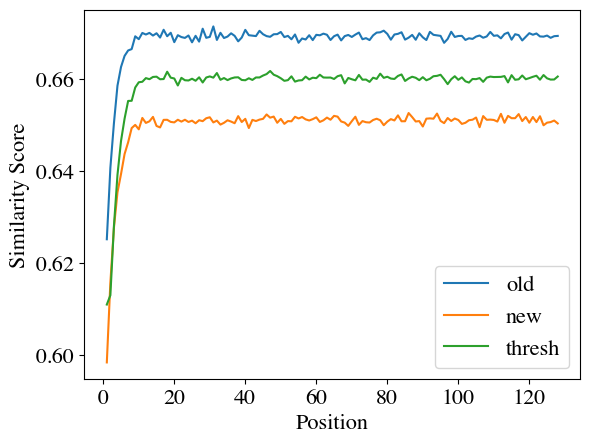

In [14]:
old_csim_pos = df_simu.query("old == True").groupby("recog_pos").csim.mean()
old_pos = np.unique(df_simu.query("old == True").recog_pos.to_numpy())
new_csim_pos = df_simu.query("old == False").groupby("recog_pos").csim.mean()
new_pos = np.unique(df_simu.query("old == False").recog_pos.to_numpy())
cthresh_pos = df_simu.groupby("recog_pos").thresh.mean()
pos = np.unique(df_simu.recog_pos.to_numpy())

plt.plot(old_pos, old_csim_pos, label="old")
plt.plot(new_pos, new_csim_pos, label="new")
plt.plot(pos, cthresh_pos, label="thresh")
plt.xlabel("Position")
plt.ylabel("Similarity Score")
plt.legend()
plt.show()

## Analysis

In [15]:
# with open("simu2_data/simu2_result.pkl", "rb") as inp:
#     df_simu = pickle.load(inp)

In [16]:
def conditions(s):
    if s.old_lag == -999:
        return np.nan
    elif np.absolute(s.old_lag) == 1:
        return "a"
    elif np.absolute(s.old_lag) > 10:
        return "r"
    else:
        return np.nan


df_simu["lag_cat"] = df_simu.apply(conditions, axis=1)
df_simu

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,subject,recog_pos,old,old_lag,study_pos,study_lag,yes,lag_cat
0,0,0,195,-1,1,0,0.619815,0.604424,0.503848,37,1,True,-999,9,56,1.0,NaN
1,0,0,493,-1,1,0,0.665409,0.619728,0.511418,37,2,True,46,55,11,0.0,r
2,0,0,376,-1,0,0,0.640102,0.665150,0.493738,37,3,True,-3,52,15,0.0,NaN
3,0,0,998,-1,1,0,0.640570,0.640244,0.500082,37,4,True,-5,47,21,0.0,NaN
4,0,0,184,-1,0,0,0.639563,0.640568,0.499749,37,5,False,-999,-99,-9999,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69883,90,5,801,-1,0,0,0.636926,0.667910,0.492255,172,124,False,-999,-99,-9999,0.0,NaN
69884,90,5,1335,-1,1,0,0.645416,0.637102,0.502079,172,125,False,-999,-99,-9999,1.0,NaN
69885,90,5,1245,-1,1,0,0.665000,0.645368,0.504908,172,126,True,-999,28,162,1.0,NaN
69886,90,5,747,-1,0,0,0.659650,0.664888,0.498690,172,127,False,-999,-99,-9999,0.0,NaN


In [17]:
# check overall HR and FAR
df_overall = df_simu.groupby(["subject", "old"]).s_resp.mean().reset_index()
hr = df_overall.groupby(["old"]).s_resp.mean()[True]
far = df_overall.groupby(["old"]).s_resp.mean()[False]
hr, far

(0.6971440018315018, 0.3167925824175824)

In [18]:
far = df_simu.query("old==False").s_resp.mean()
far

0.3167925824175824

In [19]:
df_overall = df_simu.query("old==True").groupby(["subject", "lag_cat"]).s_resp.mean().reset_index()
hr_a = df_overall.groupby(["lag_cat"]).s_resp.mean()["a"]
hr_r = df_overall.groupby(["lag_cat"]).s_resp.mean()["r"]
hr_a, hr_r

(0.535102866396882, 0.5053249449741092)

In [20]:
# # calcualte err
# err_min = 1
# csim_thresh_min = 0

# for csim_thresh in np.arange(0, 1, 0.002):

#     df_simu["s_resp"] = df_simu["csim"] > csim_thresh

#     far = df_simu.query("old==False").s_resp.mean()
#     df_overall = df_simu.query("old==True").groupby(["subject", "lag_cat"]).s_resp.mean().reset_index()
#     hr_a = df_overall.groupby(["lag_cat"]).s_resp.mean()["a"]
#     hr_r = df_overall.groupby(["lag_cat"]).s_resp.mean()["r"]

#     hr_a_gt = 0.724046
#     hr_r_gt = 0.693084
#     far_gt = 0.268861
#     err = (np.abs(hr_a - hr_a_gt) + np.abs(hr_r - hr_r_gt)) / 2 + np.abs(far - far_gt)

#     if err < err_min:
#         err_min = err
#         csim_thresh_min = csim_thresh

#     print(err)

# err_min, csim_thresh_min

# # maunal csim_thresh
# df_simu["s_resp"] = df_simu["csim"] > csim_thresh_min

# far = df_simu.query("old==False").s_resp.mean()
# df_overall = df_simu.query("old==True").groupby(["subject", "lag_cat"]).s_resp.mean().reset_index()
# hr_a = df_overall.groupby(["lag_cat"]).s_resp.mean()["a"]
# hr_r = df_overall.groupby(["lag_cat"]).s_resp.mean()["r"]

# far, hr_a, hr_r

In [21]:
# calculate err
hr_a_gt = 0.724046
hr_r_gt = 0.693084
far_gt = 0.268861
err = (np.abs(hr_a - hr_a_gt) + np.abs(hr_r - hr_r_gt)) / 2 + np.abs(far - far_gt)
err

0.2362826767320868

In [22]:
# construct local FAR
# contiguous items, but only need to consider previous items, since post items with condition is always old
recog_pos = df_simu.recog_pos.to_numpy()
old = df_simu.old.to_numpy()
lag_cat = df_simu.lag_cat.to_numpy()
lag_cat_with_new = []
for i in range(len(df_simu)):
    if recog_pos[i] > 1:
        if not old[i] and old[i - 1]:
            lag_cat_with_new.append(lag_cat[i - 1])
        else:
            lag_cat_with_new.append(lag_cat[i])
    else:
        lag_cat_with_new.append(lag_cat[i])
df_simu["lag_cat"] = lag_cat_with_new
df_simu

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,subject,recog_pos,old,old_lag,study_pos,study_lag,yes,lag_cat
0,0,0,195,-1,1,0,0.619815,0.604424,0.503848,37,1,True,-999,9,56,1.0,NaN
1,0,0,493,-1,1,0,0.665409,0.619728,0.511418,37,2,True,46,55,11,0.0,r
2,0,0,376,-1,0,0,0.640102,0.665150,0.493738,37,3,True,-3,52,15,0.0,NaN
3,0,0,998,-1,1,0,0.640570,0.640244,0.500082,37,4,True,-5,47,21,0.0,NaN
4,0,0,184,-1,0,0,0.639563,0.640568,0.499749,37,5,False,-999,-99,-9999,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69883,90,5,801,-1,0,0,0.636926,0.667910,0.492255,172,124,False,-999,-99,-9999,0.0,r
69884,90,5,1335,-1,1,0,0.645416,0.637102,0.502079,172,125,False,-999,-99,-9999,1.0,NaN
69885,90,5,1245,-1,1,0,0.665000,0.645368,0.504908,172,126,True,-999,28,162,1.0,NaN
69886,90,5,747,-1,0,0,0.659650,0.664888,0.498690,172,127,False,-999,-99,-9999,0.0,NaN


In [23]:
df_simu.groupby(["old", "lag_cat"]).old.count()  # diff from simu2_Schwartz.ipynb a bit because here is no rt removal

old    lag_cat
False  a           740
       r          4065
True   a          1159
       r          9460
Name: old, dtype: int64

In [24]:
df_t = df_simu.loc[pd.notna(df_simu.lag_cat)].copy()
df_t

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,subject,recog_pos,old,old_lag,study_pos,study_lag,yes,lag_cat
1,0,0,493,-1,1,0,0.665409,0.619728,0.511418,37,2,True,46,55,11,0.0,r
10,0,0,996,-1,1,0,0.665883,0.655057,0.502706,37,11,True,-13,27,48,1.0,r
11,0,0,1398,-1,0,0,0.641848,0.665821,0.494007,37,12,False,-999,-99,-9999,0.0,r
17,0,0,285,-1,1,0,0.676571,0.647603,0.507241,37,18,True,-26,7,75,0.0,r
22,0,0,380,-1,0,0,0.668760,0.672302,0.499115,37,23,True,11,50,37,NaN,r
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69853,90,5,48,-1,1,0,0.687724,0.660075,0.506912,172,94,True,-16,20,138,0.0,r
69865,90,5,723,-1,0,0,0.658136,0.668973,0.497291,172,106,True,19,59,111,1.0,r
69866,90,5,724,-1,1,0,0.674831,0.658197,0.504158,172,107,True,-56,3,168,1.0,r
69882,90,5,1310,-1,0,0,0.667870,0.674814,0.498264,172,123,True,-23,38,149,1.0,r


In [25]:
create_level = {0: "new_r", 1: "new_a", 2: "old_r", 3: "old_a"}
df_t["level"] = df_t.apply(lambda x: create_level[x["old"] * 2 + (x["lag_cat"] == "a")], axis=1)
df_t

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,subject,recog_pos,old,old_lag,study_pos,study_lag,yes,lag_cat,level
1,0,0,493,-1,1,0,0.665409,0.619728,0.511418,37,2,True,46,55,11,0.0,r,old_r
10,0,0,996,-1,1,0,0.665883,0.655057,0.502706,37,11,True,-13,27,48,1.0,r,old_r
11,0,0,1398,-1,0,0,0.641848,0.665821,0.494007,37,12,False,-999,-99,-9999,0.0,r,new_r
17,0,0,285,-1,1,0,0.676571,0.647603,0.507241,37,18,True,-26,7,75,0.0,r,old_r
22,0,0,380,-1,0,0,0.668760,0.672302,0.499115,37,23,True,11,50,37,NaN,r,old_r
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69853,90,5,48,-1,1,0,0.687724,0.660075,0.506912,172,94,True,-16,20,138,0.0,r,old_r
69865,90,5,723,-1,0,0,0.658136,0.668973,0.497291,172,106,True,19,59,111,1.0,r,old_r
69866,90,5,724,-1,1,0,0.674831,0.658197,0.504158,172,107,True,-56,3,168,1.0,r,old_r
69882,90,5,1310,-1,0,0,0.667870,0.674814,0.498264,172,123,True,-23,38,149,1.0,r,old_r


<Axes: xlabel='csim', ylabel='Probability'>

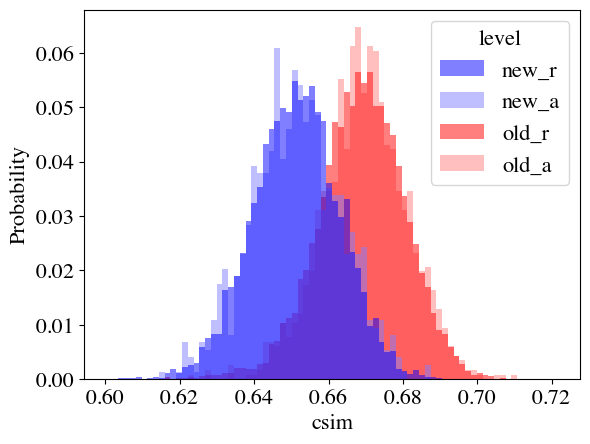

In [26]:
sns.histplot(
    data=df_t,
    x="csim",
    hue="level",
    hue_order=["new_r", "new_a", "old_r", "old_a"],
    palette=[[0, 0, 1], [0.5, 0.5, 1], [1, 0, 0], [1, 0.5, 0.5]],
    stat="probability",
    common_norm=False,
    edgecolor=None,
)
# plt.xlim(0, 0.1)

### ROC

In [27]:
thresh_arr = np.arange(0, 2, 0.001)
df_thin = df_t.loc[:, ["csim", "thresh", "level", "session"]]
csim_vec = df_thin.csim.to_numpy()
base_thresh_vec = df_thin.thresh.to_numpy()
df_roc_lst = []
for t in thresh_arr:
    # df_thin["above"] = df_thin.csim > t * df_thin.csim_rand + df_thin.csim_rand
    df_thin["above"] = csim_vec > t * base_thresh_vec
    df_sess_lv = df_thin.groupby(["session", "level"]).above.mean().to_frame(name="above")
    df_lv = df_sess_lv.groupby("level").above.mean()
    df_roc_lst.append(df_lv)
df_roc = pd.concat(df_roc_lst, axis=1, ignore_index=True)
df_roc = df_roc.transpose()
df_roc

level,new_a,new_r,old_a,old_r
0,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0
...,...,...,...,...
1995,0.0,0.0,0.0,0.0
1996,0.0,0.0,0.0,0.0
1997,0.0,0.0,0.0,0.0
1998,0.0,0.0,0.0,0.0


In [28]:
# thresh_arr = np.arange(0, 1, 0.001)
# df_thin = df_t.loc[:, ["csim", "level", "session"]]
# df_roc = pd.DataFrame()
# for t in thresh_arr:
#     df_thin["above"] = df_thin.csim > t
#     df_sess_lv = df_thin.groupby(["session", "level"]).above.mean().to_frame(name="above")
#     df_lv = df_sess_lv.groupby("level").above.mean()
#     df_roc = pd.concat([df_roc, df_lv], axis=1, ignore_index=True)
# df_roc = df_roc.transpose()
# df_roc

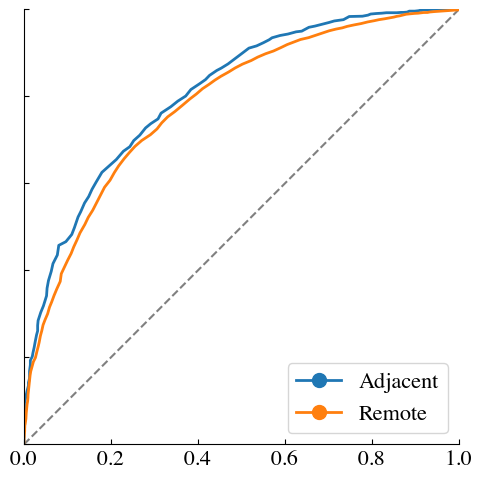

In [29]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.subplots_adjust(left=0.1, right=0.97, bottom=0.1, top=0.97)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
x = np.array([0, 1])
y = np.array([0, 1])
ax.plot(x, y, color="grey", linestyle="dashed")
sns.lineplot(data=df_roc, x="new_a", y="old_a", marker=None, ax=ax, estimator=None, label="adjacent", linewidth=2)
sns.lineplot(data=df_roc, x="new_r", y="old_r", marker=None, ax=ax, estimator=None, label="remote", linewidth=2)
plt.ylim([0, 1])
plt.xlim([0, 1])
plt.xlabel("False Alarm Rate")
plt.ylabel("Hit Rate")
ticks = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.xticks(ticks=ticks)
plt.yticks(ticks=ticks)
ax.set(xlabel=None, ylabel=None)
plt.tick_params(labelleft=False)
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="-", label="Adjacent"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="-", label="Remote"),
]
plt.legend(handles=legend_elements, loc="lower right")

if SAVEFIG:
    plt.savefig("simu2_fig/simu2_roc.pdf")

### ZROC

In [31]:
df_zroc = pd.DataFrame()
df_zroc["z_new_a"] = sp.stats.norm.ppf(df_roc["new_a"])
df_zroc["z_new_r"] = sp.stats.norm.ppf(df_roc["new_r"])
df_zroc["z_old_a"] = sp.stats.norm.ppf(df_roc["old_a"])
df_zroc["z_old_r"] = sp.stats.norm.ppf(df_roc["old_r"])
df_zroc

,z_new_a,z_new_r,z_old_a,z_old_r
0,inf,inf,inf,inf
1,inf,inf,inf,inf
2,inf,inf,inf,inf
3,inf,inf,inf,inf
4,inf,inf,inf,inf
...,...,...,...,...
1995,-inf,-inf,-inf,-inf
1996,-inf,-inf,-inf,-inf
1997,-inf,-inf,-inf,-inf
1998,-inf,-inf,-inf,-inf


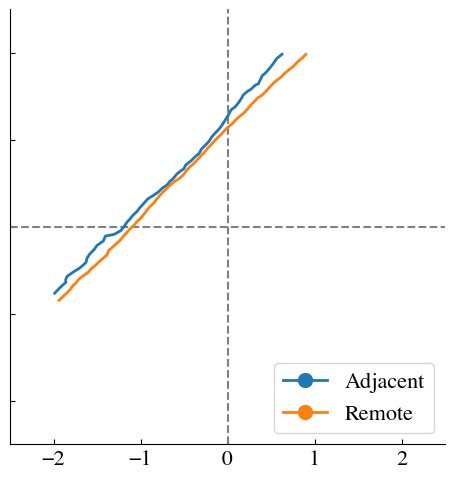

In [36]:
df_zroc_plot_a = df_zroc.query("-2 < z_new_a < 2 and -2 < z_old_a < 2")
df_zroc_plot_r = df_zroc.query("-2 < z_new_r < 2 and -2 < z_old_r < 2")

fig, ax = plt.subplots(figsize=(5, 5))
fig.subplots_adjust(left=0.1, right=0.97, bottom=0.1, top=0.97)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
plt.axvline(x=0, color="grey", linestyle="dashed")
plt.axhline(y=0, color="grey", linestyle="dashed")
sns.lineplot(data=df_zroc_plot_a, x="z_new_a", y="z_old_a", marker=None, ax=ax, estimator=None, label="adjacent", linewidth=2)
sns.lineplot(data=df_zroc_plot_r, x="z_new_r", y="z_old_r", marker=None, ax=ax, estimator=None, label="remote", linewidth=2)
plt.ylim([-2.5, 2.5])
plt.xlim([-2.5, 2.5])
plt.xlabel("False Alarm Rate")
plt.ylabel("Hit Rate")
ax.set(xlabel=None, ylabel=None)
plt.tick_params(labelleft=False)
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="-", label="Adjacent"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="-", label="Remote"),
]
plt.legend(handles=legend_elements, loc="lower right")

if SAVEFIG:
    plt.savefig("simu2_fig/simu2_zroc.pdf")

### Error Check

In [52]:
# load ground truth
with open("simu2_data/simu2_gt.pkl", "rb") as f:
    far_a_gt = pickle.load(f)
    hr_a_gt = pickle.load(f)
    far_r_gt = pickle.load(f)
    hr_r_gt = pickle.load(f)
far_a_gt, hr_a_gt, far_r_gt, hr_r_gt

(array([0.63711283, 0.40206155, 0.30077981, 0.17914973, 0.08653044]),
 array([0.87285191, 0.77504082, 0.72404606, 0.63873151, 0.53393667]),
 array([0.66120193, 0.42479231, 0.30588907, 0.17987607, 0.08935513]),
 array([0.87874116, 0.76308836, 0.69308383, 0.60104811, 0.50378656]))

In [53]:
far_a = np.sort(df_roc["new_a"].to_numpy())
hr_a = np.sort(df_roc["old_a"].to_numpy())
far_r = np.sort(df_roc["new_r"].to_numpy())
hr_r = np.sort(df_roc["old_r"].to_numpy())

# far_a_gt = np.array([0.63711283, 0.40206155, 0.30077981, 0.17914973, 0.08653044])
# hr_a_gt = np.array([0.87285191, 0.77504082, 0.72404606, 0.63873151, 0.53393667])
# far_r_gt = np.array([0.66120193, 0.42479231, 0.30588907, 0.17987607, 0.08935513])
# hr_r_gt = np.array([0.87874116, 0.76308836, 0.69308383, 0.60104811, 0.50378656])

In [54]:
hr_a_interp = []
for x in far_a_gt:
    idx = np.searchsorted(far_a, x)
    if idx < len(far_a):
        tmp_interp = hr_a[idx - 1] + (x - far_a[idx - 1]) * (hr_a[idx] - hr_a[idx - 1]) / (far_a[idx] - far_a[idx - 1])
    else:
        tmp_interp = hr_a[idx - 1]
        print("Warning: far_a_gt out of range")
    hr_a_interp.append(tmp_interp)
hr_a_interp = np.array(hr_a_interp)
hr_a_interp

array([0.94978331, 0.82789539, 0.74333149, 0.62523597, 0.46089465])

In [55]:
hr_r_interp = []
for x in far_r_gt:
    idx = np.searchsorted(far_r, x)
    if idx < len(far_r):
        tmp_interp = hr_r[idx - 1] + (x - far_r[idx - 1]) * (hr_r[idx] - hr_r[idx - 1]) / (far_r[idx] - far_r[idx - 1])
    else:
        tmp_interp = hr_r[idx - 1]
        print("Warning: far_r_gt out of range")
    hr_r_interp.append(tmp_interp)
hr_r_interp = np.array(hr_r_interp)
hr_r_interp

array([0.93732905, 0.82720521, 0.7251513 , 0.58048892, 0.39983067])

In [56]:
err = np.power(hr_a_interp - hr_a_gt, 2).sum() + np.power(hr_r_interp - hr_r_gt, 2).sum()
err

0.034402582187542684

In [57]:
np.all((hr_a_interp > hr_r_interp)[1:])

True

In [58]:
# ensure a is above r in a range
above_range = np.arange(0.08, 0.61, 0.01)
hr_a_interp_range = []
for x in above_range:
    idx = np.searchsorted(far_a, x)
    if idx < len(far_a):
        tmp_interp = hr_a[idx - 1] + (x - far_a[idx - 1]) * (hr_a[idx] - hr_a[idx - 1]) / (far_a[idx] - far_a[idx - 1])
    else:
        tmp_interp = hr_a[idx - 1]
        print("Warning: above_range out of range")
    hr_a_interp_range.append(tmp_interp)
hr_a_interp_range = np.array(hr_a_interp_range)
hr_r_interp_range = []
for x in above_range:
    idx = np.searchsorted(far_r, x)
    if idx < len(far_r):
        tmp_interp = hr_r[idx - 1] + (x - far_r[idx - 1]) * (hr_r[idx] - hr_r[idx - 1]) / (far_r[idx] - far_r[idx - 1])
    else:
        tmp_interp = hr_r[idx - 1]
        print("Warning: above_range out of range")
    hr_r_interp_range.append(tmp_interp)
hr_r_interp_range = np.array(hr_r_interp_range)

In [59]:
np.all(hr_a_interp_range > hr_r_interp_range)

True

### Alternative Plots

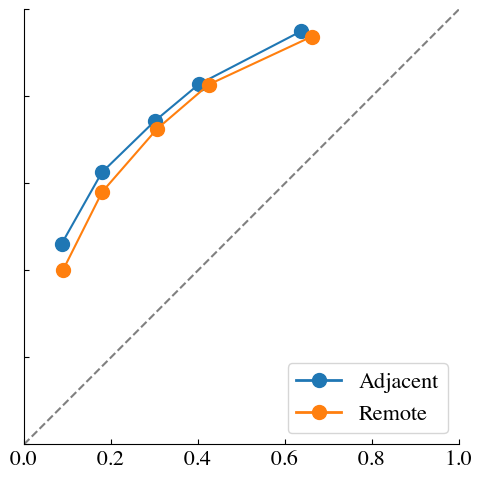

In [60]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.subplots_adjust(left=0.1, right=0.97, bottom=0.1, top=0.97)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
x = np.array([0, 1])
y = np.array([0, 1])
ax.plot(x, y, color="grey", linestyle="dashed")
# sns.lineplot(data=df_roc.query("0.08 <= new_a <= 0.67"), x="new_a", y="old_a", marker=None, ax=ax, estimator=None, label="adjacent", linewidth=2)
# sns.lineplot(data=df_roc.query("0.08 <= new_r <= 0.67"), x="new_r", y="old_r", marker=None, ax=ax, estimator=None, label="remote", linewidth=2)
plt.plot(far_a_gt, hr_a_interp, color=sns.color_palette()[0], marker="o", markersize=10, linestyle="-")
plt.plot(far_r_gt, hr_r_interp, color=sns.color_palette()[1], marker="o", markersize=10, linestyle="-")
plt.ylim([0, 1])
plt.xlim([0, 1])
plt.xlabel("False Alarm Rate")
plt.ylabel("Hit Rate")
ticks = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.xticks(ticks=ticks)
plt.yticks(ticks=ticks)
ax.set(xlabel=None, ylabel=None)
plt.tick_params(labelleft=False)
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="-", label="Adjacent"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="-", label="Remote"),
]
plt.legend(handles=legend_elements, loc="lower right")

# if SAVEFIG:
#     plt.savefig("simu2_fig/simu2_roc.pdf")

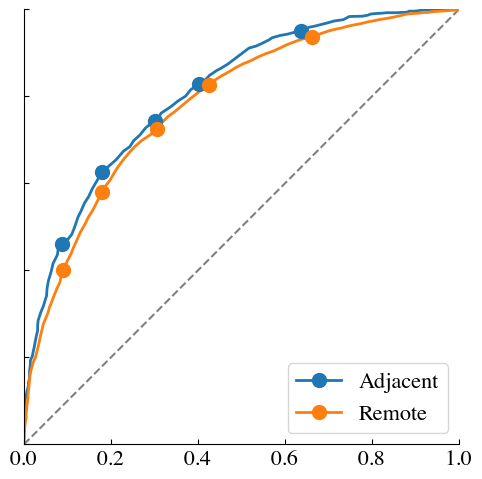

In [61]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.subplots_adjust(left=0.1, right=0.97, bottom=0.1, top=0.97)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
x = np.array([0, 1])
y = np.array([0, 1])
ax.plot(x, y, color="grey", linestyle="dashed")
sns.lineplot(data=df_roc, x="new_a", y="old_a", marker=None, ax=ax, estimator=None, label="adjacent", linewidth=2)
sns.lineplot(data=df_roc, x="new_r", y="old_r", marker=None, ax=ax, estimator=None, label="remote", linewidth=2)
plt.plot(far_a_gt, hr_a_interp, color=sns.color_palette()[0], marker="o", linestyle="None", markersize=10)
plt.plot(far_r_gt, hr_r_interp, color=sns.color_palette()[1], marker="o", linestyle="None", markersize=10)
plt.ylim([0, 1])
plt.xlim([0, 1])
plt.xlabel("False Alarm Rate")
plt.ylabel("Hit Rate")
ticks = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.xticks(ticks=ticks)
plt.yticks(ticks=ticks)
ax.set(xlabel=None, ylabel=None)
plt.tick_params(labelleft=False)
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="-", label="Adjacent"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="-", label="Remote"),
]
plt.legend(handles=legend_elements, loc="lower right")

# if SAVEFIG:
#     plt.savefig("simu2_fig/simu2_roc.pdf")

In [62]:
old_a = df_roc["old_a"].to_numpy()
new_a = df_roc["new_a"].to_numpy()
old_r = df_roc["old_r"].to_numpy()
new_r = df_roc["new_r"].to_numpy()


# find the pair closest to ground truth
def find_closest_pair(arr1, arr2, target1, target2):
    diff = np.abs(arr1 - target1) + np.abs(arr2 - target2)
    idx = np.argmin(diff)
    return idx


idx_as, idx_rs = [], []
for i in range(len(hr_a_gt)):
    idx_a = find_closest_pair(old_a, new_a, hr_a_gt[i], far_a_gt[i])
    idx_r = find_closest_pair(old_r, new_r, hr_r_gt[i], far_r_gt[i])
    idx_as.append(idx_a)
    idx_rs.append(idx_r)

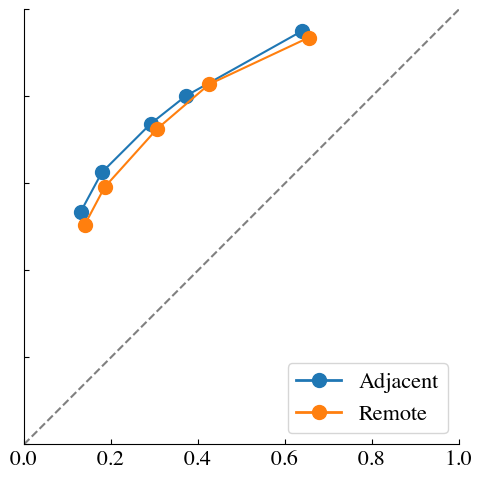

In [63]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.subplots_adjust(left=0.1, right=0.97, bottom=0.1, top=0.97)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
x = np.array([0, 1])
y = np.array([0, 1])
ax.plot(x, y, color="grey", linestyle="dashed")
plt.plot(new_a[idx_as], old_a[idx_as], color=sns.color_palette()[0], marker="o", markersize=10)
plt.plot(new_r[idx_rs], old_r[idx_rs], color=sns.color_palette()[1], marker="o", markersize=10)
plt.ylim([0, 1])
plt.xlim([0, 1])
plt.xlabel("False Alarm Rate")
plt.ylabel("Hit Rate")
ticks = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.xticks(ticks=ticks)
plt.yticks(ticks=ticks)
ax.set(xlabel=None, ylabel=None)
plt.tick_params(labelleft=False)
legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="-", label="Adjacent"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="-", label="Remote"),
]
plt.legend(handles=legend_elements, loc="lower right")

# if SAVEFIG:
#     plt.savefig("simu2_fig/simu2_roc.pdf")